## model definition

prenorm + rope + swiglu with weight tying for the embed / unembed matrix

use vanilla mha since using grouped mqa or mqa is unnecessary for the scale of this exercise and we aren't doing kv cached inference.

config:

D=256
F=4*256
L=10
N=4
=> ~10.5M params

In [1]:
from dataclasses import dataclass
from flax import nnx

@dataclass
class MoEConfig:
  experts_per_token: int
  experts: int

@dataclass
class ModelConfig:
  hidden_size: int
  ffw_size: int
  layers: int
  attn_heads: int
  vocab_size: int
  moe_config: MoEConfig | None

  def size(self):
      attn_params = 4*self.hidden_size**2 + self.hidden_size
      mlp_params = 3*self.hidden_size*self.ffw_size + self.hidden_size + self.ffw_size
      return self.layers*(attn_params + mlp_params) + self.vocab_size*self.hidden_size


class RMSNorm(nnx.Module):
  def __init__(self, config):
    hidden_size = config.hidden_size
    self.gamma = nnx.Param(jnp.ones((hidden_size,)))

  def __call__(self, x):
    inv_norm = jax.lax.rsqrt(jnp.mean(x**2, axis=-1) + 1e-6)[..., None]
    return self.gamma * x * inv_norm


class RoPE(nnx.Module):
  def _create_inv_freqs(self, base, head_size):
    assert head_size % 2 == 0
    inds = jnp.arange(head_size // 2)
    return base ** (-2 * inds / head_size)

  def _create_cos_sin(self, T, inv_freqs):
    # [1, T, 1, 1]
    positions = jnp.arange(T)[None, :, None, None]
    # [1, 1, 1, H]
    dupl_inv_freqs = jnp.concat([inv_freqs, inv_freqs])[None, None, None, :]
    # [1, T, 1, H]
    freqs = positions * dupl_inv_freqs
    return jnp.cos(freqs), jnp.sin(freqs)

  def _rotate_half(self, x):
    # x[B, T, N, H]
    H = x.shape[-1]
    even = jax.lax.dynamic_slice_in_dim(x, 0, H//2, axis=-1)
    odd = jax.lax.dynamic_slice_in_dim(x, H//2, H//2, axis=-1)
    return jnp.concat([-odd, even], axis=-1)

  def __init__(self, config, base=10_000):
    """

    for each pair of features in input

    x = [[x0],
        [x1]]

    apply rotation matrix:

    R = [[cos0, -sin0]
        [sin0, cos0]]

    Rx =>

    x0' = x0*cos0 - x1*sin0
    x1' = x1*cos0 + x0*sin0

    where 0 = 2*pi*f_j*t

    and f_j = base ** (-2i/d) where i is the index of the pair

    (at i = 0, we have frequency 1 (fast recurrences))
    (at i = d/2, we have frequency base (slow long term))

    pretend top half of x are "even" indices of x
    and bottom half of x are "odd" indices of x
    this doesn't matter since the score doesn't change
    and is just a permutation in projection weights


    x_even' = x_even*cos0 - x_odd*sin0
    x_odd' = x_odd*cos0 + x_even*sin0

    x is split so that top half is even and bottom half is odd

    then this essentially becomes x = x * cos + rotate_half(x) * sin
    where rotate half takes the odd and stacks on top and negates

    note the d dimension of cos and sin must follow this half convention as well
    """
    head_size = config.hidden_size // config.attn_heads
    self.base = base
    self.inv_freqs = self._create_inv_freqs(base, head_size)

  def __call__(self, x):
    """
    pretend top half of x are "even" indices of x
    and bottom half of x are "odd" indices of x
    this doesn't matter since the score doesn't change
    and is just a permutation in projection weights
    """

    B, T, N, H = x.shape
    cos, sin = self._create_cos_sin(T, self.inv_freqs)
    return x * cos + self._rotate_half(x) * sin


class MHA(nnx.Module):
  def __init__(self, config, *, rngs):
    self.config = config
    hidden_size = config.hidden_size
    self.pre_norm = RMSNorm(config)
    self.rope = RoPE(config)
    self.qkv_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, 3 * hidden_size)))
    self.o_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, hidden_size)))

  def _sdpa(self, q, k, v):
    """
    q[B, T, N, H]
    k[B, S, N, H]
    v[B, S, N, H]
    """
    B, T, N, H = q.shape
    S = k.shape[1]
    logits = jnp.einsum('btnh,bsnh->btsn', q, k)
    scaled_logits = (H ** -0.5) * logits
    # logits[B, T, S, N]
    # mask[1, T, S, 1]
    # non mask token positions are True
    mask = jnp.tril(jnp.ones((T, S), dtype=jnp.bool))[None, :, :, None]
    # [B, T, S, N]
    masked_scaled_logits = jnp.where(mask, scaled_logits, -jnp.inf)
    weights = jax.nn.softmax(masked_scaled_logits, axis=2)
    attn_out = jnp.einsum('btsn,bsnh->btnh', weights, v)
    return attn_out

  def __call__(self, x):
    # x = [B, T, D]
    B, T, D = x.shape
    N = self.config.attn_heads
    H = D//N
    t = self.pre_norm(x)
    qkv = jnp.einsum('btd,df->btf', t, self.qkv_proj)
    # q[B, T, D]
    q = jax.lax.dynamic_slice_in_dim(qkv, 0, D, axis=-1).reshape((B, T, N, H))
    q = self.rope(q)
    k = jax.lax.dynamic_slice_in_dim(qkv, D, D, axis=-1).reshape((B, T, N, H))
    k = self.rope(k)
    v = jax.lax.dynamic_slice_in_dim(qkv, 2*D, D, axis=-1).reshape((B, T, N, H))
    # [B, T, N, H] -> [B, T, D]
    attn_out = self._sdpa(q, k, v).reshape((B, T, D))
    out = jnp.einsum('btd,df->btf', attn_out, self.o_proj)
    return x + out


class MLP(nnx.Module):
  def __init__(self, config, *, rngs):
    self.config = config
    hidden_size = config.hidden_size
    ffw_size = config.ffw_size
    moe_config = config.moe_config
    self.pre_norm = RMSNorm(config)
    if moe_config:
      E, k = moe_config.experts, moe_config.experts_per_token
      self.router = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, E)))
      self.glu_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, hidden_size, 2*ffw_size)))
      self.down_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (E, ffw_size, hidden_size)))
    else:
      self.glu_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (hidden_size, 2*ffw_size)))
      self.down_proj = nnx.Param(0.02 * jax.random.normal(rngs.params(), (ffw_size, hidden_size)))
    self.beta = nnx.Param(jnp.ones(ffw_size))



  def __call__(self, x):
    moe_config = self.config.moe_config
    # x[B, T, D]
    # [D, 2F]
    ffw_size = self.config.ffw_size
    t = self.pre_norm(x)

    """
    MoE:
    one router for all 3 proj matrices in matrix
    router: [D, E], softmax and do weighted sum
    glu: [E, D, 2F]
    down_proj: [E, F, D]

    get top k experts for each token:
    [B, T, k]

    flatten router experts into [B*T, k]

    create inds of size [B*T, k] (repeated over k axis)
    flatten into [B*T*k]
    flatten router experts into [B*T*k]
    sort router experts into [B*T*k]
    create group sizes
    create flattened sortened input of [B*T*k, D]
    use ragged dot
    unsort input into [B*T*k, D]
    reshape to [B, T, k, D]
    multiply by expert weights and sum

    flatten input to [B*T, k]

    """


    if moe_config:
      k, E = moe_config.experts_per_token, moe_config.experts
      # [B, T, E]
      router_logits = jnp.einsum('btd,de->bte', t, self.router)
      # [B, T, E]
      router_weights = jax.nn.softmax(router_logits, axis=-1)
      # [B, T, k] [B, T, k]
      top_k_weights, top_k_experts = jax.lax.top_k(router_weights, k)

      B, T, D = t.shape
      # [B * T, D]
      flattened_x = t.reshape((B*T, D))
      # [B * T, k]
      flattened_x_inds_padded = jnp.repeat(jnp.arange(B*T)[:, None], k, axis=-1)
      # [B*T*k]
      flattened_x_inds_padded = flattened_x_inds_padded.reshape((B*T*k,))
      # [B*T*k]
      flattened_routed_experts = top_k_experts.reshape((B*T*k,))
      # [B*T*k]
      # inds has indices from 0 to B*T*k since it returns sorted inds
      sorted_routed_experts_inds = jnp.argsort(flattened_routed_experts)
      # [B*T*k]
      # sorted_routed_experts = flattened_routed_experts[sorted_routed_experts_inds]
      # [E]
      sizes = jnp.bincount(flattened_routed_experts, minlength=E, length=E)


      # [B*T*k]
      # sorted x inds relative to the experts arrays sorted by expert (which token does which expert route correspond to)
      sorted_flattened_x_inds = flattened_x_inds_padded[sorted_routed_experts_inds]
      # [B*T*k, D]
      # x sorted by expert
      sorted_flat_x = flattened_x[sorted_flattened_x_inds]
      # x[B*T*k, D]
      # W[E, D, 2F]
      # => [B*T*k, 2F]
      glu = jax.lax.ragged_dot(sorted_flat_x, self.glu_proj.value, sizes)
      # [B*T*k, F]
      f1 = jax.lax.dynamic_slice_in_dim(glu, 0, ffw_size, axis=-1)
      # [B*T*k, F]
      f2 = jax.lax.dynamic_slice_in_dim(glu, ffw_size, ffw_size, axis=-1)
      # [B*T*k, F]
      swiglu_out = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
      # [B*T*k, D]
      # each token is still in sorted order
      out = jax.lax.ragged_dot(swiglu_out, self.down_proj.value, sizes)
      # [B*T*k, D]
      out = out[jnp.argsort(sorted_routed_experts_inds)]
      # [B, T, k, D]
      out = out.reshape((B, T, k, D))
      # w[B, T, k] -> [B, T, k, 1]
      # out[B, T, k, D]
      # => [B, T, k, D] => [B, T, D]
      out = jnp.sum(top_k_weights[..., None] * out, axis=2)
    else:
      glu = jnp.einsum('btd,df->btf', t, self.glu_proj)
      # [B, T, F]
      f1 = jax.lax.dynamic_slice_in_dim(glu, 0, ffw_size, axis=-1)
      # [B, T, F]
      f2 = jax.lax.dynamic_slice_in_dim(glu, ffw_size, ffw_size, axis=-1)
      t = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
      out = jnp.einsum('btf,fd->btd', t, self.down_proj)

    return x + out


class TransformerLayer(nnx.Module):
  def __init__(self, config, *, rngs):
    self.attn_block = MHA(config, rngs=rngs)
    self.mlp_block = MLP(config, rngs=rngs)

  def __call__(self, x):
    t = self.attn_block(x)
    return self.mlp_block(t)


class Transformer(nnx.Module):
  def __init__(self, config, *, rngs):
    hidden_size = config.hidden_size
    vocab_size = config.vocab_size
    self.embed = nnx.Param(0.02 * jax.random.normal(rngs.params(), (vocab_size, hidden_size)))
    self.layers = [TransformerLayer(config, rngs=rngs) for _ in range(config.layers)]

  def __call__(self, x):
    x = self.embed[x]
    for l in self.layers:
      x = l(x)
    return jnp.einsum('btd,vd->btv', x, self.embed)


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# moe mlp test
# TEST

# END TEST

import numpy as np


class NaiveMoEMLP(nnx.Module):
    def __init__(self, config, pre_norm, router, glu_proj, down_proj, beta):
      self.config = config
      self.pre_norm = pre_norm
      self.router = router
      self.glu_proj = glu_proj
      self.down_proj = down_proj
      self.beta = beta

    def __call__(self, x):
        """
        router: [D, E]
        glu_proj: [E, D, 2F]
        down_proj: [E, F, D]
        beta: [F]

        x: [B, T, D]
        """
        k = self.config.moe_config.experts_per_token
        x_n = self.pre_norm(x)
        E, F, D = self.down_proj.value.shape
        B, T, D = x.shape
        # [B, T, E]
        router_logits = jnp.einsum('btd,de->bte', x_n, self.router)
        # [B, T, E]
        router_weights = jax.nn.softmax(router_logits, axis=-1)
        # [B, T, k] [B, T, k]
        top_k_weights, top_k_experts = jax.lax.top_k(router_weights, k)

        out = jnp.zeros((B, T, D))
        for b in range(B):
            for t in range(T):
                # [D]
                tok = x_n[b, t]
                # [k]
                top_k = top_k_experts[b, t]
                # [k, D, 2F]
                k_glu_proj = self.glu_proj[top_k]
                # [k, 2F]
                glu = jnp.einsum('d,kdf->kf', tok, k_glu_proj)
                # [k, F]
                f1 = jax.lax.dynamic_slice_in_dim(glu, 0, F, axis=-1)
                # [k, F]
                f2 = jax.lax.dynamic_slice_in_dim(glu, F, F, axis=-1)
                # [k, F]
                tmp = f1 * f2 * jax.nn.sigmoid(self.beta * f2)
                # [k, F, D]
                k_down_proj = self.down_proj[top_k]
                # [k, D]
                tmp = jnp.einsum('kf,kfd->kd', tmp, k_down_proj)
                # [k]
                k_weights = top_k_weights[b, t]
                # [k, 1] * [k, D] = [k, D] => [D]
                tok_out = jnp.sum(k_weights[:, None] * tmp, axis=0)
                out = out.at[b, t].set(tok_out)

        return x + out


@dataclass
class MoEConfig:
  experts_per_token: int
  experts: int

@dataclass
class ModelConfig:
  hidden_size: int
  ffw_size: int
  layers: int
  attn_heads: int
  vocab_size: int
  moe_config: MoEConfig | None


B, T, D, F, k, E = 2, 2, 4, 16, 2, 4

moe_config = MoEConfig(
  experts_per_token=k,
  experts=E
)

config = ModelConfig(
  hidden_size=D,
  ffw_size=F,
  layers=2,
  attn_heads=2,
  vocab_size=3,
  moe_config=moe_config
)

rngs = nnx.Rngs(0)
moe_mlp = MLP(config, rngs=rngs)
moe_naive = NaiveMoEMLP(config, moe_mlp.pre_norm, moe_mlp.router, moe_mlp.glu_proj, moe_mlp.down_proj, moe_mlp.beta)
x = jax.random.normal(rngs.params(), (B, T, D))
moe_out = moe_mlp(x)
moe_baseline = moe_naive(x)

print('moe_out shape:', moe_out.shape)
print('moe_baseline shape:', moe_baseline.shape)

np.testing.assert_array_almost_equal(moe_out, moe_baseline)

KeyboardInterrupt: 

## basic training loop

config:

D=256
F=4*256
L=10
N=4
=> ~10.5M params

In [2]:
import jax
import jax.numpy as jnp
import optax
from optax.losses import softmax_cross_entropy_with_integer_labels as softmax_ce_loss
import functools
import dataclasses

# do batch generation ENTIRELY on device, can then be jit into training step and no cpu -> accel comm!

"""

with a key:

return seq => [MAX_SEQ_LEN] (where end is padded), valid_mask

alg idea:

ex: 3 + 32 = 35

- generate ops = [3, 32]
- split into digits with res

digits = [[0, 0, 3],
          [0, 3, 2],
          [0, 3, 5]]

ops_res = [3, 32, 35]

ops shape => [3, 1]
mults = [-2, -1, 0]
mults shape => [1, 3]

# [1, 3] * [3, 1] => [3, 3]
digits = 10**mults * ops_res % 10


e3_mask = digits[0, :] > 0
e2_mask = jnp.logical_or(e3_mask, digits[1, :] > 0)
e1_mask = jnp.logical_or(e2_mask, digits[2, :] > 0)

rest of alg:
- construct full seq
- add extra dim to write to at the end for masked tokens
- use mask to create inds
- set inds, cut off last padding elem and return


Note: to make the task harder, spaces are randomly assigned to surround + and =
"""

MAX_OPERAND = 999
SPACE = 10
PLUS = 11
EQUAL = 12
EOS = 13
MAX_SEQ_LEN = 17

def gen_seq(key):
    key, op_key, space_key = jax.random.split(key, 3)
    ops = jax.random.choice(op_key, MAX_OPERAND, shape=(2,))
    ops_res = jnp.concat([ops, jnp.sum(ops, keepdims=True)])
    mults = 10**(jnp.array([-3.0, -2.0, -1.0, 0.0]))[None, :]
    digits = (mults * ops_res[:, None]).astype(jnp.int16) % 10
    e3_mask = digits[:, 0:1] > 0
    e2_mask = jnp.logical_or(e3_mask, digits[:, 1:2] > 0)
    e1_mask = jnp.logical_or(e2_mask, digits[:, 2:3] > 0)
    digits_mask = jnp.concat([
        e3_mask,
        e2_mask,
        e1_mask,
        jnp.array([True, True, True]).reshape((3, 1))
    ], axis=-1)
    spaces_mask = jax.random.choice(space_key, 2, shape=(4,)).astype(jnp.bool)
    full_seq = jnp.concat([
        digits[0],
        jnp.array([SPACE]),
        jnp.array([PLUS]),
        jnp.array([SPACE]),
        digits[1],
        jnp.array([SPACE]),
        jnp.array([EQUAL]),
        jnp.array([SPACE]),
        digits[2],
        jnp.array([EOS])
    ])
    full_seq_mask = jnp.concat([
        digits_mask[0],
        spaces_mask[0].reshape((1,)),
        jnp.array([True]),
        spaces_mask[1].reshape((1,)),
        digits_mask[1],
        spaces_mask[2].reshape((1,)),
        jnp.array([True]),
        spaces_mask[3].reshape((1,)),
        digits_mask[2],
        jnp.array([True])
    ])
    seq = jnp.full(MAX_SEQ_LEN+1, SPACE)
    inds = jnp.cumsum(full_seq_mask.astype(jnp.int8)) - 1
    inds = jnp.where(full_seq_mask, inds, -1)
    seq = seq.at[inds].set(full_seq)
    seq = seq[:MAX_SEQ_LEN]

    prompt_len = jnp.sum(e2_mask[:-1, :].astype(jnp.int8)) + jnp.sum(e1_mask[:-1, :].astype(jnp.int8)) + 2 + 2 + jnp.sum(spaces_mask.astype(jnp.int8))
    t = jnp.arange(MAX_SEQ_LEN-1)
    valid_loss_mask = jnp.logical_and(
        t >= prompt_len - 1,
        t < full_seq_mask.astype(jnp.int8).sum() - 1
    )
    return seq, valid_loss_mask


def gen_batch(bs, key):
    return jax.vmap(gen_seq)(jax.random.split(key, bs))


def decode(enc_arr):
    a = []
    for i in enc_arr.tolist():
        if i == SPACE:
            a.append(' ')
        elif i == PLUS:
            a.append('+')
        elif i == EQUAL:
            a.append('=')
        elif i == EOS:
            a.append('<|EOS|>')
        else:
            a.append(str(i))

    return "".join(a)


# reuse input state buffer so we're not storing 2x model+opt state unnecessarily
@functools.partial(jax.jit, donate_argnums=(0,), static_argnames=('bs', 'n'))
def scan(state, graphdef, key, n, bs):
    def f(carry, _):
        state, key = carry
        model, opt = nnx.merge(graphdef, state)
        key, subkey = jax.random.split(key)
        batch, loss_mask = gen_batch(bs, subkey)
        def loss_fn(model):
            logits = model(batch[:, :-1])
            labels = batch[:, 1:]
            losses = softmax_ce_loss(logits, labels)
            m = loss_mask.astype(jnp.int8)
            return jnp.sum(m * losses) / jnp.sum(m)

        loss, grads = nnx.value_and_grad(loss_fn)(model)
        opt.update(model, grads)
        _, state = nnx.split((model, opt))
        return (state, key), loss

    carry, losses = jax.lax.scan(f, (state, key), length=n)
    state, _ = carry
    return state, losses


def train_n_steps(model, opt, bs, n, key):
    graphdef, state = nnx.split((model, opt))
    state, losses = scan(state, graphdef, key, n, bs)
    nnx.update((model, opt), state)
    return losses


@dataclass
class TrainingConfig:
    max_lr: float
    min_lr: float
    steps: int
    flops: int
    warmup_steps: int
    bs: int
    seed: int
    print_every: int
    chunk_size: int = 100


def train_model(model_config, training_config):
    rngs = nnx.Rngs(params=training_config.seed, batch=training_config.seed+1)
    model = Transformer(model_config, rngs=rngs)
    lr_schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=training_config.max_lr,
        warmup_steps=training_config.warmup_steps,
        decay_steps=training_config.steps - training_config.warmup_steps,
        end_value=training_config.min_lr
    )
    opt = nnx.Optimizer(model, optax.adamw(learning_rate=lr_schedule), wrt=nnx.Param)
    chunks = int(training_config.steps // training_config.chunk_size)
    # want exact FLOPS as counted and don't want to recompile with a different n
    assert training_config.steps % training_config.chunk_size == 0
    assert training_config.print_every % training_config.chunk_size == 0
    losses = []

    print(f'--- starting run for model of size {model_config.size():1.2e} ---')
    for c in range(chunks):
        losses_jnp = train_n_steps(
            model,
            opt,
            training_config.bs,
            training_config.chunk_size,
            rngs.batch()
        )
        losses.extend(losses_jnp.tolist())

        step = (c+1)*training_config.chunk_size
        if step % training_config.print_every == 0:
          print(f'step: {step}, loss: {losses[-1]}')

    return losses

## preliminary runs
run a subset of different model sizes to see at what point their loss hits close to 0 (the problem has been completely solved) to choose appropriate C horizon lengths for Chinchilla laws

model size: 4.42e+03 training for flops: 1.00e+11 and steps: 13880
model size: 8.61e+03 training for flops: 1.00e+11 and steps: 7120
model size: 1.91e+04 training for flops: 1.00e+11 and steps: 3220
model size: 3.36e+04 training for flops: 1.00e+11 and steps: 1830
model size: 6.68e+04 training for flops: 1.00e+11 and steps: 920
model size: 1.49e+05 training for flops: 9.99e+10 and steps: 410
--- starting run for model of size 4.42e+03 ---
step: 100, loss: 2.637756824493408
step: 200, loss: 2.3612329959869385
step: 300, loss: 2.2273998260498047
step: 400, loss: 2.059682846069336
step: 500, loss: 1.960489273071289
step: 600, loss: 1.7953213453292847
step: 700, loss: 1.8101776838302612
step: 800, loss: 1.6904103755950928
step: 900, loss: 1.747205138206482
step: 1000, loss: 1.8681437969207764
step: 1100, loss: 1.8997108936309814
step: 1200, loss: 1.6422617435455322
step: 1300, loss: 1.6240233182907104
step: 1400, loss: 1.6196328401565552
step: 1500, loss: 1.6231440305709839
step: 1600, los

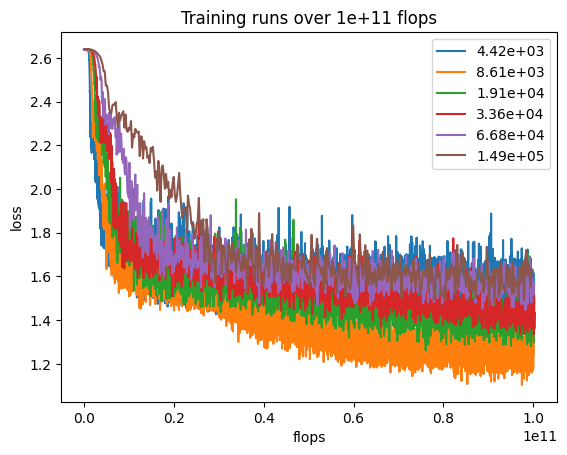

In [3]:
import matplotlib.pyplot as plt
import os
import numpy as np

MODEL_CONFIGS = [
    # 4.4K
    ModelConfig(
      hidden_size=16,
      ffw_size=4*16,
      layers=1,
      attn_heads=4,
      vocab_size=14,
      moe_config=None
    ),

    # 8K
    ModelConfig(
        hidden_size=16,
        ffw_size=4*16,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # ~19K
    ModelConfig(
        hidden_size=24,
        ffw_size=4*24,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # 33.6K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=2,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # 66.8K
    ModelConfig(
        hidden_size=32,
        ffw_size=4*32,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),

    # ~150K
    ModelConfig(
        hidden_size=48,
        ffw_size=4*48,
        layers=4,
        attn_heads=4,
        vocab_size=14,
        moe_config=None
    ),
]

FLOPS_HORIZON = 1e11
def flops_to_training_steps(model_size, flops_horizon, bs, t):
    flops_per_step = 6 * model_size * bs * t
    return int(flops_horizon // flops_per_step)


def training_steps_to_flops(model_size, training_steps, bs, t):
    flops_per_step = 6 * model_size * bs * t
    return int(flops_per_step * training_steps)


def round_training_steps_to_chunk_size(model_size, chunk_size, ideal_flops, bs, t):
    steps = flops_to_training_steps(model_size, ideal_flops, bs, t)
    rounded_steps = int((steps + chunk_size - 1) // chunk_size) * chunk_size
    return rounded_steps, training_steps_to_flops(model_size, rounded_steps, bs, t)


def build_training_configs(model_configs, chunk_size, bs, flops_horizon, print_every=100):
    t_configs = []
    for m in model_configs:
        steps, flops = round_training_steps_to_chunk_size(
          m.size(),
          chunk_size,
          flops_horizon,
          bs,
          MAX_SEQ_LEN
        )
        print(f'model size: {m.size():1.2e} training for flops: {flops:1.2e} and steps: {steps}')
        t_configs.append(
          TrainingConfig(
              max_lr=1e-3,
              min_lr=1e-4,
              steps=steps,
              flops=flops,
              warmup_steps=int(0.05*steps),
              bs=bs,
              seed=42,
              chunk_size=chunk_size,
              print_every=print_every
          )
        )

    return t_configs


def train_models(
    model_configs,
    training_configs,
    *,
    folder=None
):
    run_losses = []
    for i in range(len(training_configs)):
        model_config = model_configs[i]
        training_config = training_configs[i]
        losses = np.array(train_model(model_config, training_config))
        run_losses.append(losses)
        # save results to file
        if folder:
            with open(f'{folder}/size_{model_config.size():1.2e}.npy', 'wb') as f:
              np.save(f, losses)
              np.save(f, np.array([
                  training_config.flops,
                  training_config.bs,
                  training_config.steps
              ]))

    return run_losses


def plot_losses(
    model_configs,
    training_configs,
    losses,
    *,
    f_name
):
    fig, ax = plt.subplots()
    horizon = None
    for i in range(len(training_configs)):
        m = model_configs[i]
        t = training_configs[i]
        if not horizon:
            horizon = t.flops
        size = m.size()
        flops_per_step = int(6 * m.size() * t.bs * MAX_SEQ_LEN)
        x = flops_per_step * (np.arange(t.steps) + 1)
        run_losses = losses[i]
        ax.plot(x, run_losses, label=f'{size:1.2e}')

    ax.set_xlabel('flops')
    ax.set_ylabel('loss')
    ax.set_title(f'Training runs over {horizon:1.0e} flops')
    ax.legend()
    fig.savefig(f_name)


# do prelim runs
CHUNK_SIZE = 10
BS = 16
FLOPS_HORIZON = 1e11
preliminary_training_configs = build_training_configs(MODEL_CONFIGS, CHUNK_SIZE, BS, FLOPS_HORIZON)
losses = train_models(MODEL_CONFIGS, preliminary_training_configs)
plot_losses(MODEL_CONFIGS, preliminary_training_configs, losses, f_name=f'prelim_{FLOPS_HORIZON:1.0e}')

model size: 4.42e+03 training for flops: 1.00e+13 and steps: 1387600
model size: 8.61e+03 training for flops: 1.00e+13 and steps: 711900
model size: 1.91e+04 training for flops: 1.00e+13 and steps: 321600
model size: 3.36e+04 training for flops: 1.00e+13 and steps: 182400
model size: 6.68e+04 training for flops: 1.00e+13 and steps: 91800
model size: 1.49e+05 training for flops: 1.00e+13 and steps: 41100
--- starting run for model of size 4.42e+03 ---
step: 1000, loss: 2.637132167816162
step: 2000, loss: 2.3162200450897217
step: 3000, loss: 2.201467990875244
step: 4000, loss: 2.0322396755218506
step: 5000, loss: 1.982460379600525
step: 6000, loss: 1.809226155281067
step: 7000, loss: 1.9276710748672485
step: 8000, loss: 1.7536661624908447
step: 9000, loss: 1.679547905921936
step: 10000, loss: 1.6092827320098877
step: 11000, loss: 1.728966474533081
step: 12000, loss: 1.5958375930786133
step: 13000, loss: 1.6343538761138916
step: 14000, loss: 1.5979822874069214
step: 15000, loss: 1.5339493

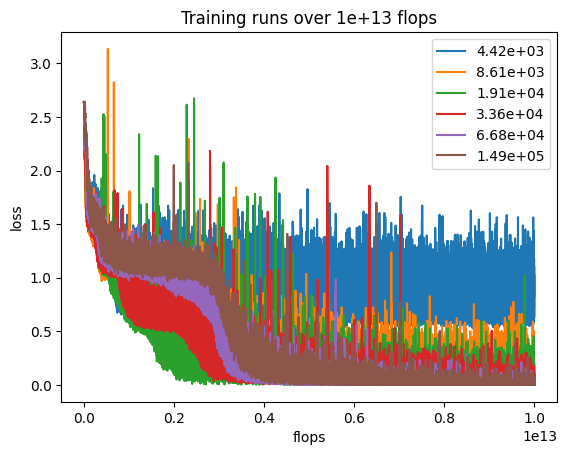

In [15]:
FLOPS_HORIZON = 1e13
CHUNK_SIZE = 100
preliminary_training_configs = build_training_configs(MODEL_CONFIGS, CHUNK_SIZE, BS, FLOPS_HORIZON, 1000)
losses = train_models(MODEL_CONFIGS, preliminary_training_configs)
plot_losses(MODEL_CONFIGS, preliminary_training_configs, losses, f_name=f'prelim_{FLOPS_HORIZON:1.0e}')

## Chinchilla Laws - Approach 1: Fix model sizes and vary number of training tokens

In [ ]:
# model size x compute run grid to use to fit power laws for each approach
"""
Use log spaced sizes and compute ranges (5 x 5)
"""

FLOP_HORIZONS = [int(1e11*(2.2**i)) for i in range(6)]

# training config
CHUNK_SIZE = 100
BS = 16
LR_MAX = 4e-3
LR_MIN = 5e-4

os.makedirs('main', exist_ok=True)
for m in MODEL_CONFIGS:
    for f in FLOP_HORIZONS:
        steps, flops = round_training_steps_to_chunk_size(
            m.size(),
            CHUNK_SIZE,
            f,
            BS,
            MAX_SEQ_LEN
        )
        print(f'model size: {m.size():1.2e} for flops: {flops:1.2e}')
        t = TrainingConfig(
            max_lr=LR_MAX,
            min_lr=LR_MIN,
            steps=steps,
            flops=flops,
            warmup_steps=int(0.05*steps),
            bs=BS,
            seed=42,
            chunk_size=CHUNK_SIZE
        )
        losses = np.array(train_model(m, t))
        with open(f'main/size_{m.size():1.2e}_flops_{f:1.2e}.npy', 'wb') as f:
            np.save(f, losses)
            np.save(f, np.array(flops))

In [ ]:
runs = {}
for m in MODEL_CONFIGS:
    for f in FLOP_HORIZONS:
        with open(f'main/size_{m.size():1.2e}_flops_{f:1.2e}.npy', 'rb') as f:
            # losses, flops
            runs[(m.size(), f)] = (np.load(f), np.load(f))

In [ ]:
@dataclass
class TrainingRunTailInterp:
    model_size: int
    flops_range: tuple[int, int]
    tail: np.array

    def covers(self, flops):
        return self.flops_range[0] <= flops <= self.flops_range[1]

    def interp_loss(self, flops):
        flops_per_step = int((self.flops_range[1] - self.flops_range[0]) // self.tail.shape[0])
        return np.interp(
            flops,
            self.flops_range[0] + flops_per_step*jnp.arange(self.tail.shape[0]),
            self.tail
        )

@dataclass
class OptPoint:
    N_opt: int
    D_opt: int
    C: int

training_run_tails = []
for (model_size, flops), losses in runs.items():
    run_len = losses.shape[0]
    # get last 15% of run
    start_steps = int(0.85*run_len)
    start_flops = training_steps_to_flops(model_size, start_steps)
    training_run_tails.append(
        TrainingRunTailInterp(
            model_size=model_size,
            flops_range=(start_flops, flops),
            tail=losses[start_steps:]
        )
    )

GLOBAL_MIN = min([t.flops_range[0] for t in training_run_tails])
GLOBAL_MAX = max([t.flops_range[1] for t in training_run_tails])
RANGE = 250

opt_pts = []
for i in range(RANGE):
    flops = int(GLOBAL_MIN * (GLOBAL_MAX - GLOBAL_MIN) // RANGE)
    cands = list(filter(lambda a: a is not None, [t if t.covers(flops) else None for t in training_run_tails]))

